# SafePrice Simulator
## Data Preparation & EDA

### 1) Import Libraries

In [271]:
import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

### 2) Reading Raw Datasets

In [272]:
root_path = os.path.dirname(os.getcwd())

raw_data_path = os.path.join(root_path, "datasets/raw")
raw_datasets = os.listdir(raw_data_path)

print(raw_datasets)

['online_retail_II.xlsx', 'Retail Prices Index.xlsx']


#### Read Retail Dateset

In [273]:
online_retail_df_2010 = pd.read_excel(os.path.join(raw_data_path, raw_datasets[0]), sheet_name='year_2010')

online_retail_df_2010.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,493410,TEST001,This is a test product.,5,2010-01-04 09:24:00,4.50,12346.0,United Kingdom
1,C493411,21539,RETRO SPOTS BUTTER DISH,-1,2010-01-04 09:43:00,4.25,14590.0,United Kingdom
2,493412,TEST001,This is a test product.,5,2010-01-04 09:53:00,4.50,12346.0,United Kingdom
3,493413,21724,PANDA AND BUNNIES STICKER SHEET,1,2010-01-04 09:54:00,0.85,NaN,United Kingdom
4,493413,84578,ELEPHANT TOY WITH BLUE T-SHIRT,1,2010-01-04 09:54:00,3.75,NaN,United Kingdom


In [274]:
online_retail_df_2010_2011 = pd.read_excel(os.path.join(raw_data_path, raw_datasets[0]), sheet_name='year_2010_2011')

online_retail_df_2010_2011.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [275]:
retail_df = pd.concat([online_retail_df_2010, online_retail_df_2010_2011], ignore_index=True)
retail_df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1022138,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1022139,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1022140,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1022141,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1022142,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


##### Price & Quantity Cols Filtered

In [276]:
retail_df = retail_df[retail_df['Quantity'] > 0]
retail_df = retail_df[retail_df['Price'] > 0]

In [277]:
Q1_quantity = retail_df.Quantity.quantile(0.25)
Q3_quantity = retail_df.Quantity.quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity

lower_bound_quantity = Q1_quantity - (1.5 * IQR_quantity)
upper_bound_quantity = Q3_quantity + (1.5 * IQR_quantity)

retail_df = retail_df[retail_df['Quantity'].between(lower_bound_quantity, upper_bound_quantity)]

Q1_price = retail_df.Price.quantile(0.25)
Q3_price = retail_df.Price.quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_bound_price = Q1_price - (1.5 * IQR_price)
upper_bound_price = Q3_price + (1.5 * IQR_price)

retail_df = retail_df[retail_df['Price'].between(lower_bound_price, upper_bound_price)]

In [278]:
print("2010 dataset lenght: ",len(online_retail_df_2010))
print("2010-2011 dataset lenght: ",len(online_retail_df_2010_2011))
print("Combine Dataset length: ", len(retail_df))

2010 dataset lenght:  480233
2010-2011 dataset lenght:  541910
Combine Dataset length:  884635


#### Read Retail Prices Index Dateset

In [279]:
retail_price_index_df = pd.read_excel(os.path.join(raw_data_path, raw_datasets[1])).iloc[984:1008]
retail_price_index_df.head()

,Title,Retail Prices Index: Long run series: 1800 to 2024: Jan 1974=100
984,2010 JAN,859.6
985,2010 FEB,864.7
986,2010 MAR,870.7
987,2010 APR,878.9
988,2010 MAY,882.1


In [280]:
retail_price_index_df.rename(columns={
    'Title': 'Date',
    'Retail Prices Index: Long run series: 1800 to 2024: Jan 1974=100': 'Retail Price Index'
}, inplace=True)

In [281]:
retail_price_index_df.head()

,Date,Retail Price Index
984,2010 JAN,859.6
985,2010 FEB,864.7
986,2010 MAR,870.7
987,2010 APR,878.9
988,2010 MAY,882.1


### 3) Data Preparation

#### Retail DataFrame

##### Filter only UK data

In [282]:
retail_df.Country.unique()

<StringArray>
[      'United Kingdom',               'Sweden',               'France',
              'Germany',                 'EIRE',              'Belgium',
                'Spain',                  'USA',              'Denmark',
               'Greece',                'Japan',          'Netherlands',
              'Finland',      'Channel Islands',          'Unspecified',
               'Cyprus',             'Portugal',                'Malta',
              'Bahrain',                  'RSA',              'Austria',
 'United Arab Emirates',          'Switzerland',            'Australia',
               'Poland',                'Italy',              'Bermuda',
            'Hong Kong',            'Singapore',               'Israel',
             'Thailand',            'Lithuania',               'Norway',
              'Nigeria',          'West Indies',              'Lebanon',
                'Korea',               'Brazil',               'Canada',
              'Iceland',         'Sau

In [283]:
retail_df = retail_df[retail_df['Country']=='United Kingdom']

In [284]:
retail_df.isnull().sum()

Invoice             0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
Price               0
Customer ID    192072
Country             0
dtype: int64

##### Exporting Cleaned Dataset

In [285]:
cleaned_data_path = os.path.join(root_path, "datasets/cleaned")
retail_df.to_csv(os.path.join(cleaned_data_path, "retail_cleaned.csv"))

##### Filtered the retail_df

In [286]:
retail_df_filter = retail_df.drop(['Invoice', 'Description', 'Customer ID', 'Country'], axis=1)
retail_df_filter.head()

,StockCode,Quantity,InvoiceDate,Price
0,TEST001,5,2010-01-04 09:24:00,4.50
2,TEST001,5,2010-01-04 09:53:00,4.50
3,21724,1,2010-01-04 09:54:00,0.85
4,84578,1,2010-01-04 09:54:00,3.75
5,21723,1,2010-01-04 09:54:00,0.85


##### Date Col Formatting

In [287]:
retail_df_filter['InvoiceDate'] = pd.to_datetime(retail_df_filter['InvoiceDate'])
retail_df_filter['FullDate'] = retail_df_filter['InvoiceDate'].dt.date
retail_df_filter['InvoiceDate'] = retail_df_filter['InvoiceDate'].dt.to_period('M')

In [288]:
retail_df_filter.head()

,StockCode,Quantity,InvoiceDate,Price,FullDate
0,TEST001,5,2010-01,4.50,2010-01-04
2,TEST001,5,2010-01,4.50,2010-01-04
3,21724,1,2010-01,0.85,2010-01-04
4,84578,1,2010-01,3.75,2010-01-04
5,21723,1,2010-01,0.85,2010-01-04


In [289]:
retail_df_filter.dtypes

StockCode         object
Quantity           int64
InvoiceDate    period[M]
Price            float64
FullDate          object
dtype: object

#### Retail Prices Index DataFrame

##### Exporting Cleaned Datasets

In [290]:
retail_price_index_df = retail_price_index_df.reset_index(drop=True)
retail_price_index_df.to_csv(os.path.join(cleaned_data_path, "retail_price_index_cleaned.csv"))

##### Date Col Formatting

In [291]:
retail_price_index_df.dtypes

Date                     str
Retail Price Index    object
dtype: object

In [292]:
retail_price_index_df.head()

,Date,Retail Price Index
0,2010 JAN,859.6
1,2010 FEB,864.7
2,2010 MAR,870.7
3,2010 APR,878.9
4,2010 MAY,882.1


In [293]:
retail_price_index_df.Date = pd.to_datetime(retail_price_index_df['Date'], format='mixed')
retail_price_index_df.Date = retail_price_index_df['Date'].dt.to_period()

In [294]:
retail_price_index_df.dtypes

Date                  period[M]
Retail Price Index       object
dtype: object

In [295]:
retail_price_index_df.head()

,Date,Retail Price Index
0,2010-01,859.6
1,2010-02,864.7
2,2010-03,870.7
3,2010-04,878.9
4,2010-05,882.1


#### Merge Two DataFrames

In [296]:
retail_df_final = retail_df_filter.merge(retail_price_index_df, how='left', left_on='InvoiceDate', right_on='Date').drop(['Date'], axis=1)
retail_df_final.tail()

,StockCode,Quantity,InvoiceDate,Price,FullDate,Retail Price Index
819386,23145,12,2011-12,0.95,2011-12-09,944.4
819387,22466,12,2011-12,1.95,2011-12-09,944.4
819388,22061,8,2011-12,2.95,2011-12-09,944.4
819389,23275,24,2011-12,1.25,2011-12-09,944.4
819390,20685,10,2011-12,7.08,2011-12-09,944.4


In [297]:
retail_df_final['Retail Price Index'] = retail_df_final['Retail Price Index'].astype('float64')

##### Remove Duplicates and Aggregate

In [298]:
retail_df_final.head()

,StockCode,Quantity,InvoiceDate,Price,FullDate,Retail Price Index
0,TEST001,5,2010-01,4.50,2010-01-04,859.6
1,TEST001,5,2010-01,4.50,2010-01-04,859.6
2,21724,1,2010-01,0.85,2010-01-04,859.6
3,84578,1,2010-01,3.75,2010-01-04,859.6
4,21723,1,2010-01,0.85,2010-01-04,859.6


In [299]:
retail_df_final = retail_df_final.groupby(['StockCode', 'FullDate']).agg({
    "Quantity": "sum",
    "InvoiceDate": "first",
    "Price": "mean",
    "Retail Price Index": "first"
}).reset_index()

In [300]:
retail_df_final=retail_df_final.sort_values(by="FullDate")

#### Add Holidays Column

In [301]:
uk_holidays = holidays.UnitedKingdom(years=[2010, 2011])

black_friday_dates = [
    pd.to_datetime('2009-11-27').date(),
    pd.to_datetime('2010-11-26').date(),
    pd.to_datetime('2011-11-25').date()
]

mega_monday_dates = [
    pd.to_datetime('2009-12-07').date(),
    pd.to_datetime('2010-12-06').date(),
    pd.to_datetime('2011-12-05').date()
]

def assign_event(date_val):
    if date_val in black_friday_dates:
        return 'Black Friday'
    elif date_val in mega_monday_dates:
        return 'Mega Monday'
    elif date_val in uk_holidays:
        return uk_holidays.get(date_val)
    else:
        return 'Normal Day'

In [302]:
retail_df_final['Event_Name'] = retail_df_final['FullDate'].map(lambda date: assign_event(date))

### 4) Exploratory Data Analysis

In [303]:
retail_df_final.head()

,StockCode,FullDate,Quantity,InvoiceDate,Price,Retail Price Index,Event_Name
0,10002,2010-01-04,3,2010-01,0.85,859.6,Normal Day
338640,46118,2010-01-04,4,2010-01,0.85,859.6,Normal Day
104308,21729,2010-01-04,3,2010-01,3.25,859.6,Normal Day
338357,40016,2010-01-04,36,2010-01,0.42,859.6,Normal Day
31492,21004,2010-01-04,2,2010-01,4.25,859.6,Normal Day


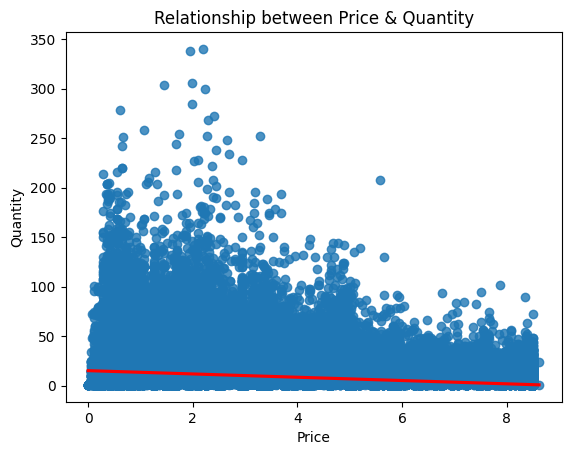

In [304]:
sns.regplot(retail_df_final, x='Price', y='Quantity', line_kws={"color": "red"})
plt.title('Relationship between Price & Quantity')
plt.show()

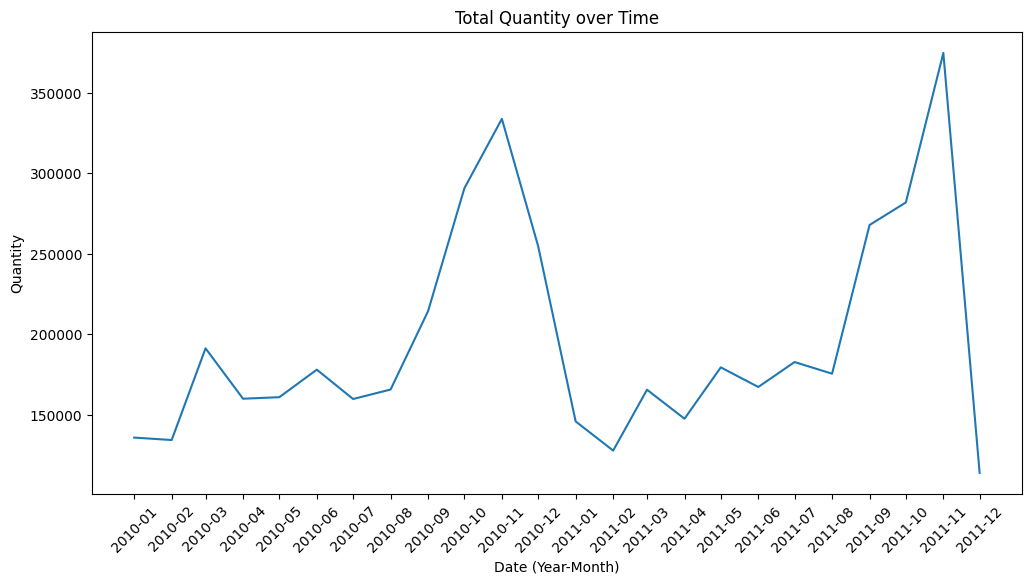

In [305]:
fig, _ = plt.subplots(figsize=(12,6))
retail_df_final_by_date = pd.DataFrame(retail_df_final.groupby('InvoiceDate')['Quantity'].sum()).reset_index()
retail_df_final_by_date['InvoiceDate'] = retail_df_final_by_date['InvoiceDate'].dt.to_timestamp()
sns.lineplot(data=retail_df_final_by_date, x='InvoiceDate', y='Quantity')
plt.xticks(
    ticks=retail_df_final_by_date['InvoiceDate'], 
    labels=retail_df_final_by_date['InvoiceDate'].dt.strftime('%Y-%m'),
    rotation=45
)
plt.xlabel('Date (Year-Month)')
plt.title('Total Quantity over Time')
plt.show()

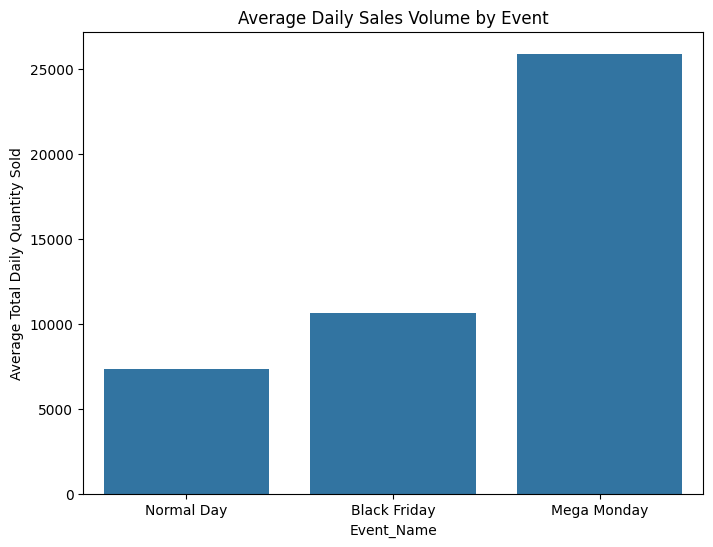

In [306]:
daily_totals = retail_df_final.groupby(['FullDate','Event_Name'])['Quantity'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=daily_totals, x='Event_Name', y='Quantity', order=['Normal Day', 'Black Friday', 'Mega Monday'], errorbar=None, estimator=np.median)
plt.title('Average Daily Sales Volume by Event')
plt.ylabel('Average Total Daily Quantity Sold')
plt.show()

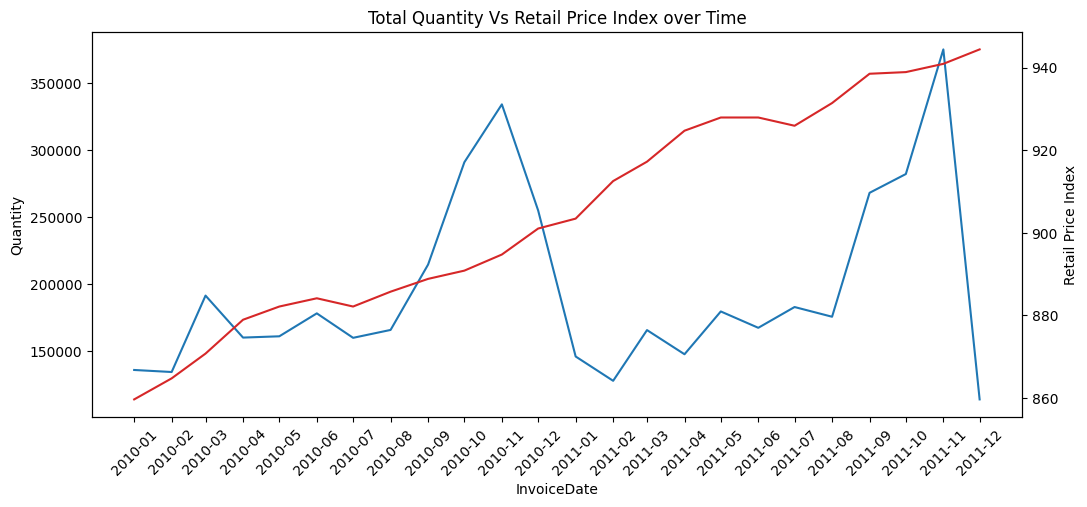

In [307]:
fig, ax1 = plt.subplots(figsize=(12,5))

retail_df_final_by_date = pd.DataFrame(retail_df_final.groupby('InvoiceDate')['Quantity'].sum()).reset_index()
retail_df_final_by_date['InvoiceDate'] = retail_df_final_by_date['InvoiceDate'].dt.to_timestamp()

sns.lineplot(data=retail_df_final_by_date, x='InvoiceDate', y='Quantity', ax=ax1)
plt.xticks(
    ticks=retail_df_final_by_date['InvoiceDate'], 
    labels=retail_df_final_by_date['InvoiceDate'].dt.strftime('%Y-%m'),
    rotation=45
)

ax2 = ax1.twinx()
retail_df_final_by_rpi =  pd.DataFrame(retail_df_final.groupby('InvoiceDate')['Retail Price Index'].mean()).reset_index()
retail_df_final_by_rpi['InvoiceDate'] = retail_df_final_by_rpi['InvoiceDate'].dt.to_timestamp()
sns.lineplot(data=retail_df_final_by_rpi, x='InvoiceDate', y='Retail Price Index', ax=ax2, color='tab:red')

plt.xlabel('Date (Year-Month)')
plt.title('Total Quantity Vs Retail Price Index over Time')
plt.show()

In [308]:
retail_df_final.dtypes

StockCode                object
FullDate                 object
Quantity                  int64
InvoiceDate           period[M]
Price                   float64
Retail Price Index      float64
Event_Name                  str
dtype: object

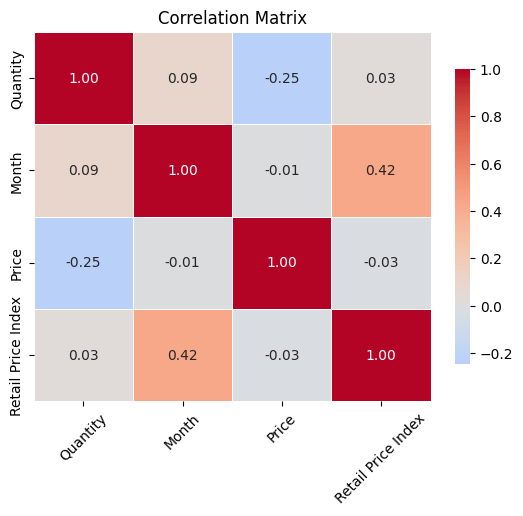

In [309]:
retail_df_final['FullDate'] = pd.to_datetime(retail_df_final['FullDate'])
retail_df_final['Month'] = retail_df_final['FullDate'].dt.month
corr = retail_df_final[['Quantity', 'Month', 'Price', 'Retail Price Index']].corr()

sns.heatmap(corr, 
            annot=True,       
            fmt=".2f",         
            cmap='coolwarm',    
            center=0,            
            linewidths=0.5,   
            cbar_kws={"shrink": .8}) 

plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

#### Export Final Cleaned Dateset 

In [312]:
retail_df_final["is_holiday"] = np.where(retail_df_final['Event_Name']=='Normal Day', 0, 1)

retail_df_final = retail_df_final.drop(['InvoiceDate', 'Month', 'StockCode', 'Event_Name'], axis=1)

retail_df_final.rename({"FullDate": "InvoiceDate"}, inplace=True, axis=1)

retail_df_final.to_csv(os.path.join(cleaned_data_path, "final_cleaned_retail_dataset.csv"), index=None)

In [313]:
retail_df_final

,InvoiceDate,Quantity,Price,Retail Price Index,is_holiday
0,2010-01-04,3,0.85,859.6,0
338640,2010-01-04,4,0.85,859.6,0
104308,2010-01-04,3,3.25,859.6,0
338357,2010-01-04,36,0.42,859.6,0
31492,2010-01-04,2,4.25,859.6,0
...,...,...,...,...,...
294051,2011-12-09,3,1.63,944.4,0
332766,2011-12-09,1,2.49,944.4,0
185651,2011-12-09,5,2.46,944.4,0
332780,2011-12-09,3,2.49,944.4,0
